In [ ]:
!pip install pyspark

26/05/21 02:08:52 WARN Utils: Your hostname, Abdullahs-MacBook-Pro-7.local resolves to a loopback address: 127.0.0.1; using 192.168.0.50 instead (on interface en0)
26/05/21 02:08:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/21 02:08:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+--------+-----------+----+--------------+-------------------+
|District|crime_index|Hour|domestic_index|features           |
+--------+-----------+----+--------------+-------------------+
|23      |0.0        |14  |0.0           |[23.0,0.0,14.0,0.0]|
|1       |1.0        |20  |0.0           |[1.0,1.0,20.0,0.0] |
|7       |3.0        |3   |0.0           |[7.0,3.0,3.0,0.0]  |
|12      |2.0        |16  |1.0           |[12.0,2.0,16.0,1.0]|
|1       |0.0        |11  |0.0           |[1.0,0.0,11.0,0.0] |
+--------+-----------+----+--------------+-------------------+
only showing top 5 rows



26/05/21 02:08:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Training rows: 23
Testing rows: 7


26/05/21 02:09:01 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/21 02:09:01 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS



Logistic Regression
AUC: 0.6666666666666666
Accuracy: 0.7142857142857143
F1 Score: 0.7023809523809523
Precision: 0.8285714285714285
Recall: 0.7142857142857142
Training Time: 1.9756920337677002
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|    2|
|    0|       0.0|    3|
|    1|       1.0|    2|
+-----+----------+-----+



26/05/21 02:09:04 WARN DecisionTreeMetadata: DecisionTree reducing maxBins from 32 to 23 (= number of training instances)



Random Forest
AUC: 1.0
Accuracy: 1.0
F1 Score: 1.0
Precision: 1.0
Recall: 1.0
Training Time: 1.2394812107086182
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|    3|
|    1|       1.0|    4|
+-----+----------+-----+



26/05/21 02:09:06 WARN DecisionTreeMetadata: DecisionTree reducing maxBins from 32 to 23 (= number of training instances)



GBT
AUC: 1.0
Accuracy: 1.0
F1 Score: 1.0
Precision: 1.0
Recall: 1.0
Training Time: 7.325049161911011
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|    3|
|    1|       1.0|    4|
+-----+----------+-----+


MODEL COMPARISON
['Logistic Regression', 0.6666666666666666, 0.7142857142857143, 0.7023809523809523, 0.8285714285714285, 0.7142857142857142, 1.9756920337677002]
['Random Forest', 1.0, 1.0, 1.0, 1.0, 1.0, 1.2394812107086182]
['GBT', 1.0, 1.0, 1.0, 1.0, 1.0, 7.325049161911011]

FEATURE IMPORTANCES
District : 0.21387081261421736
crime_index : 0.5490790277719909
Hour : 0.2114588063878066
domestic_index : 0.025591353225985224


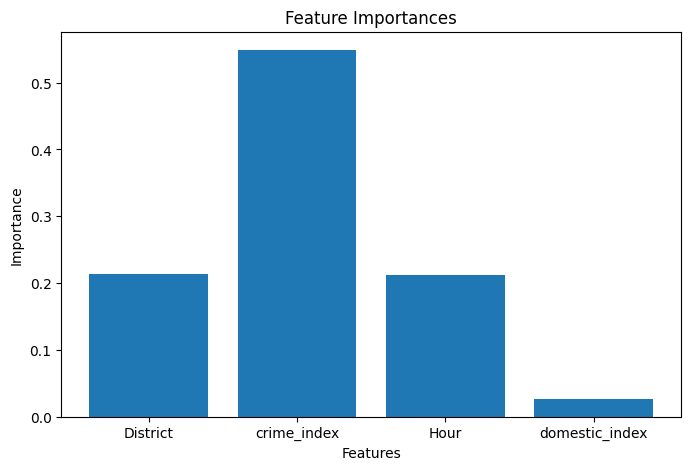

In [1]:

# ============================================
# Tasks 5-7
# Author: Abdullah Al Mutabagani
# ============================================
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, hour, to_timestamp
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import time
spark = SparkSession.builder \
    .appName("M2 Spark ML") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")
# ============================================
# Task 5
# ============================================
df = spark.read.csv(
    "../../data/chicago_crimes_sample.csv",
    header=True,
    inferSchema=True
)
df = df.withColumn("label", col("Arrest").cast("integer"))
df = df.withColumn(
    "Hour",
    hour(to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a"))
)
df = df.withColumn(
    "Domestic_str",
    col("Domestic").cast("string")
)
df = df.na.drop(subset=[
    "Primary Type",
    "Domestic_str",
    "District",
    "Hour",
    "label"
])
crime_indexer = StringIndexer(
    inputCol="Primary Type",
    outputCol="crime_index",
    handleInvalid="skip"
)
domestic_indexer = StringIndexer(
    inputCol="Domestic_str",
    outputCol="domestic_index",
    handleInvalid="skip"
)
assembler = VectorAssembler(
    inputCols=["District", "crime_index", "Hour", "domestic_index"],
    outputCol="features",
    handleInvalid="skip"
)
pipeline = Pipeline(stages=[
    crime_indexer,
    domestic_indexer,
    assembler
])
pipeline_model = pipeline.fit(df)
processed_df = pipeline_model.transform(df)
processed_df.select(
    "District",
    "crime_index",
    "Hour",
    "domestic_index",
    "features"
).show(5, truncate=False)
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)
train_df.cache()
print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())
# ============================================
# Task 6
# ============================================
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.01
)
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=5
)
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=50,
    maxDepth=5
)
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "GBT": gbt
}
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)
results = []
rf_model = None
for name, model in models.items():
    start = time.time()
    trained_model = model.fit(train_df)
    predictions = trained_model.transform(test_df)
    end = time.time()
    auc = auc_evaluator.evaluate(predictions)
    accuracy = accuracy_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)
    precision = precision_evaluator.evaluate(predictions)
    recall = recall_evaluator.evaluate(predictions)
    training_time = end - start
    print("\n==============================")
    print(name)
    print("==============================")
    print("AUC:", auc)
    print("Accuracy:", accuracy)
    print("F1 Score:", f1)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Training Time:", training_time)
    predictions.groupBy("label", "prediction").count().show()
    results.append([name, auc, accuracy, f1, precision, recall, training_time])
    if name == "Random Forest":
        rf_model = trained_model
print("\n==============================")
print("MODEL COMPARISON")
print("==============================")
for row in results:
    print(row)
# ============================================
# Task 7
# ============================================
feature_names = ["District", "crime_index", "Hour", "domestic_index"]
importances = rf_model.featureImportances.toArray()
print("\n==============================")
print("FEATURE IMPORTANCES")
print("==============================")
for name, importance in zip(feature_names, importances):
    print(name, ":", importance)
plt.figure(figsize=(8, 5))
plt.bar(feature_names, importances)
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()
spark.stop()